In [1]:
# basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#tensorflow imports
from sklearn.model_selection import train_test_split
from keras.layers import Input, Dropout, Dense, concatenate, Embedding
from keras.layers import Flatten, Activation
from keras.optimizers import Adam
from keras.models import Model
from keras.utils import to_categorical
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.models import load_model
from keras.layers import LSTM
from keras.layers import GRU
from keras.layers import MaxPooling1D
from keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#torch and huggingface transformers imports
import torch
from transformers import (
    GPT2LMHeadModel, GPT2TokenizerFast,
    DataCollatorForLanguageModeling,
    Trainer, TrainingArguments,
)

#other imports
from datasets import Dataset
import math
import random
import os
import re
import kagglehub


### Loading data

In [3]:
path = kagglehub.dataset_download("thec03u5/seinfeld-chronicles")
print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 1.38M/1.38M [00:01<00:00, 1.35MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/thec03u5/seinfeld-chronicles/versions/1
['episode_info.csv', 'scripts.csv']


In [4]:
df = pd.read_csv(os.path.join(path, 'scripts.csv'))
df.Character = df.Character.astype(str)
df.Dialogue = df.Dialogue.astype(str)
df = df[["Character","Dialogue"]]

### EDA

In [ ]:
# see eda in seinfeld_eda.ipynb

In [ ]:
# specific eda for cleaning puposes

# loading characters unique values to llm
a = df['Character'].to_dict()
unique_values = set(a.values())
print(unique_values)
len(unique_values)

{'SHLOMO', 'ICE CREAM VENDER #1', 'FRED SAVAGE', "JERRY'S BRAIN", 'CABBY', 'PITT (looking at Elaine and smiling)', 'FAN #1', 'POKER PLAYER #1', 'CLUB ANNOUNCER', 'POPPIE', 'RONNIE (points to his nose)', 'GEORGE (pulls over)', 'GAIL (hands a plate to another chef)', '[GEORGE', 'VOICE FROM POKER GAME', 'DEENA', 'TOR', 'CORINNE', "LANDIS'S INTERCOM", 'MONA', 'AUCTIONEER', 'JENNA (O.C.)', 'JERRY (holds up the syrup bottle)', 'KID #2', 'WORKER', "ELAINE'S VOICE", 'BRADY', 'Announcer', 'HOT DOG VENDOR', 'LENA', 'JERRY (not happy)', 'HELEN & AARON', 'JERRY (picks up the phone)', 'CLAIE', 'PREGNANT WOMAN', '(Elaine is robbed of her peek into the first class section by a drawn curtain and she goes to her seat. However, someone comes after her and', 'MRS. ENRIGHT', 'MERYL (looking in the drawer)', 'CASHIER', 'JERRY (sarcastically)', 'VIC', 'MAN #1', "KRAMER (points at Jerry like he's found him out)", 'MARTIN', 'MCADAM', 'PHONE MAN', 'ELIANE', 'CAR SALESMAN', 'ELAINE (in a southern accent)', 'TON

1639

In [ ]:
# llm creates dictionery by the categories i had defined it
character_categories = {
    "main_characters": {
        'ELAINE': [
            'EALINE', 'ELAIEN', 'ELAINE', 'ELAINE ', 'ELANE', 'ELIANE', 'Elaine',
        ],
        'GEORGE': [
            'GEOGE', 'GEORGE', 'GEORGE ', 'GEROGE', 'GOERGE',
        ],
        'JERRY': [
            'JERR', 'JERRY', 'JERRY ', 'JERY',
        ],
        'KRAMER': [
            'KRAMER', 'KRAMER ', 'KRMAER',
        ],
        'NEWMAN': [
            'NEWMAN', 'Newman',
        ],
    },

    "named_side_characters": [
        '2nd MOVIE PATRON', 'AARON', 'ABBY', 'ADA', 'ADAM', 'ADE', 'AL', 'AL ROKER', 'ALAN',
        'ALEC', 'ALEX', 'ALEX TREBEK', 'ALICIA', 'ALISON', 'ALL FOUR MEN', 'ALL THREE', 'ALLISON',
        'ALLSION', 'ALTON', 'AMANDA', 'AMY', 'ANGELA', 'ANNA', 'ANTONIO', 'ARNIE', 'ARONSON',
        'ARTIE', 'ASSISTANT DRESSER', 'AUDREY', 'AUNT MAY', 'AVA', 'Another man', 'BABS', 'BABU',
        "BABU'S BROTHER", "BABU'S FRIEND", 'BANIA', 'BARBARA', 'BARRY', 'BECK', 'BECKY', 'BEN',
        'BENES', 'BETH', 'BETSY', 'BETTE', 'BILL', 'BILLY', 'BLAINE', 'BOB', 'BOBBY', 'BONNIE',
        'BOOKIE', 'BOOKMAN', 'BOSS', "BOSS' WIFE", 'BRADY', 'BRETT', 'BRIDGET', 'BRODY', 'BRUCE',
        'BRYANT', 'BUCKLES', 'BUDDY', 'BUILDING A', 'BUILDING B', 'BUILDING C', 'Babu Bhatt',
        'Banker', 'Boysenberry', 'CAB DRIVER', 'CALVIN KLEIN', 'CANDICE BERGEN', 'CARL', 'CAROL',
        'CARRERAS', 'CARRIE', 'CASTRO', 'CEDRIC', 'CELIA', 'CHAIRMAN', 'CHARLES', 'CHARLIE',
        'CHARMAINE', 'CHELSEA', 'CHERYL', 'CHILES', 'CHOATE', 'CHRISTIE', 'CINDY', 'CLAIE',
        'CLAIRE', 'CLARE', 'CLAYTON', 'CLICKY', 'CLOTWORTHY', 'CLYDE', 'COCO', 'CONNIE', 'CONRAD',
        'CORBIN BERNSEN', 'CORINNE', 'COWORKER', 'CRAIG', 'CRESPI', 'CYNTHIA', 'DAN', 'DANA',
        'DANIELLE', 'DANNY TARTABULL', 'DAPHNE', 'DARREN', 'DARRYL', 'DAVID', 'DAVOLA',
        'DEAN JONES', 'DEBBY', 'DEENA', 'DEENSFREI', 'DENISE', 'DENNIS', 'DEVOLA', 'DIANE', 'DICK',
        'DISPATCHER', 'DOCTER', 'DOLORES', 'DONALD', 'DONNA', 'DONNA ', 'DOORMAN', 'DOORMAN 2',
        'DORIS', 'DR. ALLENWOOD', 'DR. BAKERSOLL', 'DR. BURKE', 'DR. COOPERMAN', 'DR. DEMBROW',
        'DR. RESNICK', 'DR. RESTON', 'DR. WEXLER', 'DRY CLEANE', 'DUGAN', 'DUNCAN', 'DUSTIN',
        'DWAYNE', 'Dugan', 'EARL', 'ED', 'EDDIE', 'EDDIT', 'ELDRIDGE', 'ELLEN', 'EMILY', 'ENZO',
        'ERIC', 'ESTELLE', 'ETHAN', 'EULOGIST', 'EVA', 'EVELYN', 'FARKUS', 'FARMER',
        'FATHER CURTIS', 'FATHER HERNANDEZ', 'FATHER JESSUP', 'FDR', 'FELDMAN', 'FOWLER', 'FRANK',
        'FRANKIE', 'FRED', 'FRED SAVAGE', 'FULTON', 'GAIL', 'GARDNER', 'GARY', 'GAVIN', 'GENE',
        'GENNICE', 'GEORGE WENDT', 'GEPETTO', 'GIGGIO', 'GILLIAN', 'GINA', 'GINO', 'GIULIANI',
        'GLADYS', 'GLENDA', 'GLENN', 'GREENY', 'GREG', 'GROSSBARD', 'GUILLERMO', 'GUY ON PHONE',
        'GWEN', 'HAARWOOD', 'HAFFLER', 'HAL', 'HALLIE', 'HANKE', 'HAROLD', 'HEAD', 'HEATHER',
        'HELEN', 'HELENA', 'HENRY', 'HERB', 'HEYMAN', 'HILDE', 'HOLLY', 'HORST', 'HOYT',
        'Huckleberry', 'IAN', 'ILENE', 'IPSWITCH', 'ISAAC', 'ISABEL', 'IZZY', 'IZZY JR.',
        'IZZY SR.', 'J. PETERMAN', 'JACK', 'JACKIE', 'JACKIE ', 'JAKE', 'JAMES', 'JANE', 'JANET',
        'JANICE', 'JAY', 'JAY LENO', 'JEANINE', 'JEANNIE', 'JEFF', 'JENNA', 'JENNY', 'JESSIE',
        'JETER', 'JIM', 'JIMMY', 'JOAN', 'JOANNE', 'JODI', 'JOE', 'JOE DEVOLA', 'JOE DIVOLA',
        "JOE'S WIFE", 'JOEL', 'JOEY', 'JOHN', 'JOHN TYLER', 'JOHNNY', 'JOY MAYO', 'JOYCE', 'JUDY',
        'JULIANNA', 'JULIE', 'JULIO', 'James', 'KAREN', 'KARL', 'KATE', 'KATHY LEE', 'KATIE',
        'KATY', 'KATYA', 'KEITH', 'KELLY', 'KEN', 'KERI', 'KERNIS', 'KESSLER', 'KEVIN', 'KIM',
        'KIMBROUGH', 'KLEIN', 'KRISTIN', 'KRUGER', 'KURT', 'LAMAR', 'LANDIS', 'LANETTE', 'LARRY',
        'LAURA', "LEAPIN' LARRY", 'LELAND', 'LENA', 'LEO', 'LESLIE', 'LETTERMAN', 'LEVITAN', 'LEW',
        'LINDSAY', 'LIPPMAN', 'LISA', 'LISI', 'LIZ', 'LLOYD', 'LOIS', 'LORETTA', 'LORRAINE',
        'LOTUS', 'LOU', 'LOUISE', 'LT. COLEMAN', 'LT. MARTEL', 'LUBECK', 'LUPE', 'LYLE', 'MABEL',
        'MACKENZIE', 'MAESTRO', "MAITRE D'", 'MALCOLM', 'MAN BEHIND THE DOOR', 'MAN ON RAFT',
        'MANDEL', 'MANNY', 'MANYA', 'MANYA ', 'MARCELINO', 'MARCELLINO', 'MARCY', 'MARGARET',
        'MARIAN', 'MARIE', 'MARIO', 'MARION', 'MARISA', 'MARK', 'MARLA', 'MARLENE', 'MARRY',
        'MARTIN', 'MARTY', 'MARY', 'MARY ANNE', 'MARYEDITH', 'MATTHEW', 'MAURA', 'MAXWELL',
        'MCADAM', 'MEL', 'MELANIE', 'MELISSA', 'MERYL', 'MICHAEL', 'MICKEY', 'MIKE', 'MILOS',
        'MINKLER', 'MIRANDA', 'MISHA', 'MISS RHODE ISLAND', 'MOHEL', 'MOLLIKA', 'MOLLY', 'MOM',
        'MONA', 'MONICA', "MONK'S MANAGER", 'MOONEY', 'MORGAN', 'MORTY', 'MOVIE PHONE GUY',
        'MR BURNS', 'MR OH', 'MR REICHMAN', 'MR ROSS', 'MR STAR', 'MR TANAKA', 'MR YAMAGUCHI',
        'MR. ABBOTT', 'MR. ARM', 'MR. BEVILACQUA', 'MR. COHEN', 'MR. CROSS', 'MR. CUSHMAN',
        'MR. ELINOFF', 'MR. GOLDSTEIN', 'MR. GRAHAM', 'MR. GREEN', 'MR. LIPPMAN', 'MR. MORGAN',
        'MR. PETERMAN', 'MR. PITT', 'MR. PLESS', 'MR. ROSS', 'MR. S', 'MR. SANGER',
        'MR. STEINBRENNER', 'MR. THOMASSOULO', 'MR. TUTTLE', 'MR.THOMASSOULO', 'MRS ALLISTER',
        'MRS HAMILTON', 'MRS REICHMAN', 'MRS. ANVINO', 'MRS. C', 'MRS. CHOATE', 'MRS. COSTANZA',
        'MRS. ENRIGHT', 'MRS. O', 'MRS. PAYTON', 'MRS. PETERMAN', 'MRS. ROSS', 'MRS. S',
        'MRS. SANGER', 'MRS. SOKOL', 'MRS. SWEEDLER', 'MRS. ZANFINO', 'MRS.ARM', 'MS. BAINES',
        'MS. DE GRANMONT', 'MS. JORDAN', 'MYRA', 'Mr. VISAKI', 'Mrs. SANGER', 'Mrs. SWEEDLER',
        'NANA', 'NANCY', 'NAOMI', 'NED', 'NEIL', 'NICK', 'NIKKI', 'NINA', 'NOEL', 'NOREEN', 'Nana',
        "O'NEILL", 'OLIVE', 'Off stage', 'PAM', 'PAMELA', 'PARRY', 'PAT', 'PAT HAZELL', 'PATRICE',
        'PATTI', 'PATTY', 'PAUL', 'PAULA', 'PEGGY', 'PENNY', 'PENSKY', 'PETE', 'PETER', 'PETERMAN',
        'PHIL', 'PHILBIN', 'PHONE MAN', 'PING', 'PINTER', 'PITT', 'POLICEMAN', 'POP', 'POPPIE',
        'POSTAL WORKER DANNY', 'PUDDY', 'Phil', 'RACHEL', 'RALPH', 'RAMON', 'RAQUEL', 'RAVA',
        'RAY', 'RAYMOND', 'READER', 'REBECCA', 'REFEREE', 'REGIS', 'REILLY', 'REMY', 'RENE',
        'RESTON', 'RHISA', 'RICARDI', 'RICHIE', 'RICK', 'RICKEY', 'RICKY', "RICKY'S BOSS", 'RITA',
        'RIVERA', 'ROBERT', 'ROBERTA', 'ROBIN', "ROBIN'S MOTHER", 'ROCHELLE', 'ROGER', 'RON',
        'RONNIE', 'ROXANNE', 'ROY', 'RUBY', 'RUDY', 'RULA', 'RUSSEL', 'RUSSELL', 'RUSTY', 'RUTHIE',
        'SAL BASS', 'SALLY', 'SAM', 'SANDI', 'SANDOS BROTHER 1', 'SANDOS BROTHER 2', 'SANDRA',
        'SANDY', 'SANSEI', 'SARA', 'SASHA', 'SCOTT', 'SETH', 'SHARON', 'SHEILA', 'SHELLBACH',
        'SHELLY', 'SHERRY', 'SHLOMO', 'SHOWALTER', 'SID', 'SIDRA', 'SIENA', 'SILVIO', 'SIMON',
        'SISTER ROBERTA', 'SLIPPERT PETE', 'SLIPPERY PETE', 'SOPHIE', 'SPIKE', 'SPONSER',
        'SPONSOR', 'STACEY', 'STAN', 'STEFANIE', 'STEIN', 'STEINBRENNER', 'STELLA', 'STEVE',
        'STEVEN', 'STU', 'SUE ELLEN', 'SUNNY', 'SUSAN', 'SUSIE', 'SYLVIA', 'Stu', 'TABACHNICK',
        'TAMMY', 'TAN', 'TARA', 'TARTABULL', 'TARTBULL', 'TAWNI', 'TAXI DRIVER', 'TEDDY', 'TELLER',
        'TESTIKOV', 'THE DRAKE', 'THE FREAK', 'THE GIRLS', 'THOMASSOULO', 'TIA', 'TIERNEY', 'TIM',
        'TIMMY', 'TINA', 'TOBY', 'TODD', 'TOM', 'TONY', 'TOR', 'TRUCK DRIVER', 'TUTTLE', 'Tina',
        'UMPIRE', 'UNCLE LEO', 'UNCLE MAC', 'USHA', 'VALERIE', 'VANDELAY', 'VANESSA', 'VARGUS',
        'VEGETABLE LASAGNA', 'VIC', 'VICTORIA', 'VINCENT', 'VIVIAN', 'VOGEL', 'VOICE', 'VOIGHT',
        'WALTER', 'WATKINS', 'WENDY', 'WEST', 'WHATLEY', 'WILCOX', 'WILHELM', 'WILKIE', 'WILLIAMS',
        'WILLIE', 'WILLIE SR', 'WILTON', 'WINONA', 'WOMAN AT BEACH', 'WOMAN AT PHONE', 'WYCK',
        'Woman Behind ELAINE', 'Women', 'ZACH', 'ZEKE', 'ZUBIN',
    ],

    "unnamed_role_characters": [
        'AGENCY REP', 'AGENT', 'ALL', 'ANGRY MAN', 'APPLICANT', 'ASSISTANT', 'ATTENDANT',
        'AUCTIONEER', 'BAILIFF', 'BANK EMPLOYEE', 'BARTENDER', 'BIKER', 'BLIND MAN',
        'BLIND VIOLIN PLAYER', 'BOMB COP', 'BOTH', 'BOUNCER', 'BOY', 'BOYFRIEND', 'BUBBLE BOY',
        'BUSINESS MAN', 'BUSINESSMAN', 'BUXOM WOMAN', 'CABBIE', 'CABBY', 'CAPTAIN', 'CAR SALESMAN',
        'CAR THIEF', 'CAR WASHER', 'CASHIER', 'CASTING DIRECTOR', 'CHAUFFEUR', 'CHIROPRACTOR',
        'CLEANING WOMAN', 'CLERK', 'CLERK 2', 'CONTEST WINNER', 'COP', 'COP 2', 'COPS',
        'COUNTER WOMAN', 'COUNTERPERSON', 'CREW LEADER', 'CROWD', 'CUSTOMER', 'DELIVERY BOY',
        'DELIVERY GUY', 'DELIVERY MAN', 'DENIM VEST', 'DENTIST', 'DEPUTY', 'DETECTIVE', 'DIRECTOR',
        'DOCTOR', 'DOG OWNER', 'DOLL', 'DRIVER', 'DRY CLEANER', 'Driver', 'ELECTRICIAN',
        'EMPLOYEE', 'EVERYBODY', 'EVERYONE', 'EXECUTIVE 1', 'EXECUTIVE 2', 'FAN', 'FATHER',
        'FEMALE CUSTOMER', 'FEMALE WORKER', 'FIREMAN', 'FLIGHT ATTENDANT', 'FLORIST', 'FOREMAN',
        'FRIEND', 'FRIEND 1', 'FURNITURE GUY', 'GAURD', 'GERMAN WOMAN', 'GIRL', 'GIRLFRIEND',
        'GROUP', 'GUARD', 'GUY', 'Guy1', 'HAIRDRESSER', 'HEALTH INSPECTOR', 'HOLE DIGGER',
        'HOMELESS MAN', 'HOMELESS MAN 2', 'HOOKER', 'HOSTESS', 'HOT DOG VENDOR', 'HOTEL CLERK',
        'HOUSEKEEPER', 'HUSBAND', 'INTERPRETER', 'INTERVIEWER', 'JUDGE', 'KID', 'LAB TECHNICIAN',
        'LADY', 'LADY 1', 'LADY 2', 'LANDLORD', 'LASER GUY', 'LEADER', 'LIBRARIAN', 'MAHJONG LADY',
        'MAID', 'MAILMAN', 'MALE WORKER', 'MAN', 'MAN 1', 'MAN 2', 'MAN 3', 'MAN 4',
        'MAN AT THE COUNTER', 'MAN ON THE STREET', 'MAN1', 'MAN2', 'MAN3', 'MAN4', 'MANAGER',
        'MECHANIC', 'MEMBER 1', 'MEMBER 2', 'MOTHER', 'MOVIE PATRON', 'MUSIC GUY', 'Man',
        'NAKED MAN', 'NEIGHBOR', 'NEPHEW', 'NEWSSTAND OWNER', 'NUN', 'NURSE', 'NURSE 1', 'OFFICER',
        'OLD GUY', 'OLD MAN', 'OLD WOMAN', 'OLDER MAN', 'OLDER WOMAN', 'ORDERLY', 'ORGANIZER',
        'OTHER GUY', 'OTHER SECURITY GUARD', 'OWNER', 'PARAMEDIC', 'PARTY GUEST', 'PASSENGER',
        'PASSENGER 2', 'PASSERBY', 'PATIENT', 'PEOPLE AT TABLE', 'PHARMACIST', 'PHOTOGRAPHER',
        'PLAYER', 'POLICE', 'POLICE OFFICER', 'POSTAL EMPLOYEE', 'POSTAL WORKER', 'POSTMAN',
        'POSTMASTER GENERAL', 'PREGNANT WOMAN', 'PRIEST', 'PRISONER', 'PRISONER 1', 'PRISONER 2',
        'PRISONER 3', 'PROSTITUTE', 'PUERTO RICAN MAN', 'Police officer', 'RABBI', 'RECEPTIONIST',
        'RENTAL CAR AGENT', 'REPAIRMAN', 'REPORTER', 'REPORTERS', 'RESIDENT', 'RESTAURATEUR',
        'ROBBER', 'Receptionist', 'SAILOR', 'SALES WOMAN', 'SALESMAN', 'SALESWOMAN', 'SECRETARY',
        'SECURITY GUARD', 'SKYCAP', 'SOME GUY', 'SON', 'SOUP NAZI', 'SPEAKER', 'STAGEHAND',
        'STATIONER', 'STEWARDESS', 'STOCK BOY', 'STORE MANAGER', 'STRANGER', 'STREET TOUGH',
        'STUDENT 1', 'STUDENT 2', 'STUDENT 3', 'STUDIO GUARD', 'SUPER', 'SUPERVISOR', 'TALL GIRL',
        'TEACHER', 'TENANT 1', 'TENANT 2', 'THEATER MANAGER', 'THERAPIST', 'THUG', 'TICKET LADY',
        'TICKET MAN', 'UKRAINIAN', 'USHER', 'VENDER', 'VET', 'VIOLIN PLAYER', 'WAITER', 'WAITRESS',
        'WAITRESS ', 'WELLS', 'WIFE', 'WOMAN', 'WOMAN 1', 'WOMAN 2', 'WORKER', 'YELLING GUY',
        'YOUNG COP',
    ],

    "stage_directions": [
        'ANNOUNCEMENT', 'ANNOUNCER', 'ANNOUNCER ON TV', 'ANSWERING MACHINE', 'AUDIENCE',
        'Announcer', 'BUZZER', 'CLUB ANNOUNCER', 'COMPUTER VOICE', 'DJ ON RADIO', 'ECHO',
        "ELAINE'S VOICE", "ELAINE's brain", 'Elaine thinking', "GEORGE'S VOICE",
        'HIGH PITCHED VOICE', 'HOSPITAL VOICEOVER', 'INTERCOM', "JERRY'S BRAIN", "JERRY'S MACHINE",
        "JERRY'S PENIS", "JERRY'S brain", "JERRY's brain", 'JERRY\x92S MESSAGE',
        "LANDIS'S INTERCOM", 'MACHINE', 'NARRATOR', 'NEWS', 'Newscaster', 'PHONE', 'PHONE TAPE',
        'POLICE RADIO', 'RADIO', 'RADIO ANNOUNCER', "SAM'S VOICE", 'SUBWAY ANNOUNCEMENT',
        'TAPE PLAYER', 'TAPE RECORDER', 'TV', 'TV ANNOUNCER', 'TV ELAINE', 'TV JERRY',
        'TV NEWSCASTER', 'TV VOICE', 'VOICE ON INTERCOM', 'VOICE ON SPEAKER', 'VOICE ON THE PHONE',
        'Voice',
    ],

    "garbage": [
        '<IMG SRC=http', 'AENT', 'C.K.', 'Dedication', 'Dx', 'EGO', 'ElainELAINE',
        'Elaine + JERRY', 'Ex', 'GUAD', 'GX', 'Genderson', 'Hx', 'KRAMER + JERRY', 'MAR',
        'MORGANEWMAN', 'NEMWAN', 'NEWMANEWMAN', 'Notice', 'Opening Monolog', 'Opening scene',
        'Performed by', 'Published', 'Scene', 'SeConrad', 'Sponer', 'Sung by', 'TEL', 'TVVOICE',
        'WOMANEWMAN', "We gotta go! It's 8", 'Wx', 'http', 'so far',
    ],

}

In [ ]:
# decide which cahracters to keep : count who said the most lines

named_set   = {c.strip() for c in character_categories["named_side_characters"]}
unnamed_set = {c.strip() for c in character_categories["unnamed_role_characters"]}

char_counts = df['Character'].str.strip().value_counts()

named_counts   = char_counts[char_counts.index.isin(named_set)]
unnamed_counts = char_counts[char_counts.index.isin(unnamed_set)]


In [ ]:
unnamed_counts.head(10)

,count
Character,
WOMAN,157
MAN,143
DOCTOR,91
CLERK,90
WAITRESS,67
GUY,52
COP,43
ATTENDANT,43
MANAGER,43


In [ ]:
named_counts.head(10)

,count
Character,
MORTY,505
HELEN,471
FRANK,436
SUSAN,379
ESTELLE,286
PETERMAN,191
PUDDY,162
JACK,124
MICKEY,111


### Cleaning

In [5]:
def cleaning(df):

    # a bit changing the dictionary according to the eda part
    characters_map = {
    'ELAINE': [
            'EALINE', 'ELAIEN', 'ELAINE', 'ELAINE ', 'ELANE', 'ELIANE','Elaine','elaine'
        ],
        'GEORGE': [
            'GEOGE', 'GEORGE', 'GEORGE ', 'GEROGE', 'GOERGE','george',
        ],
        'JERRY': [
            'JERR', 'JERRY', 'JERRY ', 'JERY','jerry',
        ],
        'KRAMER': [
            'KRAMER', 'KRAMER ', 'KRMAER',
        ],
        'NEWMAN': [
            'NEWMAN', 'Newman',
        ],
        'SOUP_NAZI': [
            'SOUP NAZI'
        ],

    }

    keep_characters = {
        'MORTY','HELEN','FRANK','SUSAN','ESTELLE','PETERMAN','PUDDY','JACK','MICKEY','BANIA',
        'WOMAN','MAN','DOCTOR','CLERK','WAITRESS','GUY','MANAGER','COP','ATTENDANT','SOUP NAZI',
    }

    garbage = {
            '2nd MOVIE PATRON', 'AARON', 'ABBY', 'ADA', 'ADAM', 'ADE', 'AL', 'AL ROKER', 'ALAN',
            'ALEC', 'ALEX', 'ALEX TREBEK', 'ALICIA', 'ALISON', 'ALL FOUR MEN', 'ALL THREE', 'ALLISON',
            'ALLSION', 'ALTON', 'AMANDA', 'AMY', 'ANGELA', 'ANNA', 'ANTONIO', 'ARNIE', 'ARONSON',
            'ARTIE', 'ASSISTANT DRESSER', 'AUDREY', 'AUNT MAY', 'AVA', 'Another man', 'BABS', 'BABU',
            "BABU'S BROTHER", "BABU'S FRIEND", 'BARBARA', 'BARRY', 'BECK', 'BECKY', 'BEN',
            'BENES', 'BETH', 'BETSY', 'BETTE', 'BILL', 'BILLY', 'BLAINE', 'BOB', 'BOBBY', 'BONNIE',
            'BOOKIE', 'BOOKMAN', 'BOSS', "BOSS' WIFE", 'BRADY', 'BRETT', 'BRIDGET', 'BRODY', 'BRUCE',
            'BRYANT', 'BUCKLES', 'BUDDY', 'BUILDING A', 'BUILDING B', 'BUILDING C', 'Babu Bhatt',
            'Banker', 'Boysenberry', 'CAB DRIVER', 'CALVIN KLEIN', 'CANDICE BERGEN', 'CARL', 'CAROL',
            'CARRERAS', 'CARRIE', 'CASTRO', 'CEDRIC', 'CELIA', 'CHAIRMAN', 'CHARLES', 'CHARLIE',
            'CHARMAINE', 'CHELSEA', 'CHERYL', 'CHILES', 'CHOATE', 'CHRISTIE', 'CINDY', 'CLAIE',
            'CLAIRE', 'CLARE', 'CLAYTON', 'CLICKY', 'CLOTWORTHY', 'CLYDE', 'COCO', 'CONNIE', 'CONRAD',
            'CORBIN BERNSEN', 'CORINNE', 'COWORKER', 'CRAIG', 'CRESPI', 'CYNTHIA', 'DAN', 'DANA',
            'DANIELLE', 'DANNY TARTABULL', 'DAPHNE', 'DARREN', 'DARRYL', 'DAVID', 'DAVOLA',
            'DEAN JONES', 'DEBBY', 'DEENA', 'DEENSFREI', 'DENISE', 'DENNIS', 'DEVOLA', 'DIANE', 'DICK',
            'DISPATCHER', 'DOCTER', 'DOLORES', 'DONALD', 'DONNA', 'DONNA ', 'DOORMAN', 'DOORMAN 2',
            'DORIS', 'DR. ALLENWOOD', 'DR. BAKERSOLL', 'DR. BURKE', 'DR. COOPERMAN', 'DR. DEMBROW',
            'DR. RESNICK', 'DR. RESTON', 'DR. WEXLER', 'DRY CLEANE', 'DUGAN', 'DUNCAN', 'DUSTIN',
            'DWAYNE', 'Dugan', 'EARL', 'ED', 'EDDIE', 'EDDIT', 'ELDRIDGE', 'ELLEN', 'EMILY', 'ENZO',
            'ERIC', 'ETHAN', 'EULOGIST', 'EVA', 'EVELYN', 'FARKUS', 'FARMER',
            'FATHER CURTIS', 'FATHER HERNANDEZ', 'FATHER JESSUP', 'FDR', 'FELDMAN', 'FOWLER',
            'FRANKIE', 'FRED', 'FRED SAVAGE', 'FULTON', 'GAIL', 'GARDNER', 'GARY', 'GAVIN', 'GENE',
            'GENNICE', 'GEORGE WENDT', 'GEPETTO', 'GIGGIO', 'GILLIAN', 'GINA', 'GINO', 'GIULIANI',
            'GLADYS', 'GLENDA', 'GLENN', 'GREENY', 'GREG', 'GROSSBARD', 'GUILLERMO', 'GUY ON PHONE',
            'GWEN', 'HAARWOOD', 'HAFFLER', 'HAL', 'HALLIE', 'HANKE', 'HAROLD', 'HEAD', 'HEATHER',
            'HELENA', 'HENRY', 'HERB', 'HEYMAN', 'HILDE', 'HOLLY', 'HORST', 'HOYT',
            'Huckleberry', 'IAN', 'ILENE', 'IPSWITCH', 'ISAAC', 'ISABEL', 'IZZY', 'IZZY JR.',
            'IZZY SR.', 'J. PETERMAN', 'JACKIE', 'JACKIE ', 'JAKE', 'JAMES', 'JANE', 'JANET',
            'JANICE', 'JAY', 'JAY LENO', 'JEANINE', 'JEANNIE', 'JEFF', 'JENNA', 'JENNY', 'JESSIE',
            'JETER', 'JIM', 'JIMMY', 'JOAN', 'JOANNE', 'JODI', 'JOE', 'JOE DEVOLA', 'JOE DIVOLA',
            "JOE'S WIFE", 'JOEL', 'JOEY', 'JOHN', 'JOHN TYLER', 'JOHNNY', 'JOY MAYO', 'JOYCE', 'JUDY',
            'JULIANNA', 'JULIE', 'JULIO', 'James', 'KAREN', 'KARL', 'KATE', 'KATHY LEE', 'KATIE',
            'KATY', 'KATYA', 'KEITH', 'KELLY', 'KEN', 'KERI', 'KERNIS', 'KESSLER', 'KEVIN', 'KIM',
            'KIMBROUGH', 'KLEIN', 'KRISTIN', 'KRUGER', 'KURT', 'LAMAR', 'LANDIS', 'LANETTE', 'LARRY',
            'LAURA', "LEAPIN' LARRY", 'LELAND', 'LENA', 'LEO', 'LESLIE', 'LETTERMAN', 'LEVITAN', 'LEW',
            'LINDSAY', 'LIPPMAN', 'LISA', 'LISI', 'LIZ', 'LLOYD', 'LOIS', 'LORETTA', 'LORRAINE',
            'LOTUS', 'LOU', 'LOUISE', 'LT. COLEMAN', 'LT. MARTEL', 'LUBECK', 'LUPE', 'LYLE', 'MABEL',
            'MACKENZIE', 'MAESTRO', "MAITRE D'", 'MALCOLM', 'MAN BEHIND THE DOOR', 'MAN ON RAFT',
            'MANDEL', 'MANNY', 'MANYA', 'MANYA ', 'MARCELINO', 'MARCELLINO', 'MARCY', 'MARGARET',
            'MARIAN', 'MARIE', 'MARIO', 'MARION', 'MARISA', 'MARK', 'MARLA', 'MARLENE', 'MARRY',
            'MARTIN', 'MARTY', 'MARY', 'MARY ANNE', 'MARYEDITH', 'MATTHEW', 'MAURA', 'MAXWELL',
            'MCADAM', 'MEL', 'MELANIE', 'MELISSA', 'MERYL', 'MICHAEL', 'MIKE', 'MILOS',
            'MINKLER', 'MIRANDA', 'MISHA', 'MISS RHODE ISLAND', 'MOHEL', 'MOLLIKA', 'MOLLY', 'MOM',
            'MONA', 'MONICA', "MONK'S MANAGER", 'MOONEY', 'MORGAN', 'MOVIE PHONE GUY',
            'MR BURNS', 'MR OH', 'MR REICHMAN', 'MR ROSS', 'MR STAR', 'MR TANAKA', 'MR YAMAGUCHI',
            'MR. ABBOTT', 'MR. ARM', 'MR. BEVILACQUA', 'MR. COHEN', 'MR. CROSS', 'MR. CUSHMAN',
            'MR. ELINOFF', 'MR. GOLDSTEIN', 'MR. GRAHAM', 'MR. GREEN', 'MR. LIPPMAN', 'MR. MORGAN',
            'MR. PETERMAN', 'MR. PITT', 'MR. PLESS', 'MR. ROSS', 'MR. S', 'MR. SANGER',
            'MR. STEINBRENNER', 'MR. THOMASSOULO', 'MR. TUTTLE', 'MR.THOMASSOULO', 'MRS ALLISTER',
            'MRS HAMILTON', 'MRS REICHMAN', 'MRS. ANVINO', 'MRS. C', 'MRS. CHOATE', 'MRS. COSTANZA',
            'MRS. ENRIGHT', 'MRS. O', 'MRS. PAYTON', 'MRS. PETERMAN', 'MRS. ROSS', 'MRS. S',
            'MRS. SANGER', 'MRS. SOKOL', 'MRS. SWEEDLER', 'MRS. ZANFINO', 'MRS.ARM', 'MS. BAINES',
            'MS. DE GRANMONT', 'MS. JORDAN', 'MYRA', 'Mr. VISAKI', 'Mrs. SANGER', 'Mrs. SWEEDLER',
            'NANA', 'NANCY', 'NAOMI', 'NED', 'NEIL', 'NICK', 'NIKKI', 'NINA', 'NOEL', 'NOREEN', 'Nana',
            "O'NEILL", 'OLIVE', 'Off stage', 'PAM', 'PAMELA', 'PARRY', 'PAT', 'PAT HAZELL', 'PATRICE',
            'PATTI', 'PATTY', 'PAUL', 'PAULA', 'PEGGY', 'PENNY', 'PENSKY', 'PETE', 'PETER',
            'PHIL', 'PHILBIN', 'PHONE MAN', 'PING', 'PINTER', 'PITT', 'POLICEMAN', 'POP', 'POPPIE',
            'POSTAL WORKER DANNY', 'Phil', 'RACHEL', 'RALPH', 'RAMON', 'RAQUEL', 'RAVA',
            'RAY', 'RAYMOND', 'READER', 'REBECCA', 'REFEREE', 'REGIS', 'REILLY', 'REMY', 'RENE',
            'RESTON', 'RHISA', 'RICARDI', 'RICHIE', 'RICK', 'RICKEY', 'RICKY', "RICKY'S BOSS", 'RITA',
            'RIVERA', 'ROBERT', 'ROBERTA', 'ROBIN', "ROBIN'S MOTHER", 'ROCHELLE', 'ROGER', 'RON',
            'RONNIE', 'ROXANNE', 'ROY', 'RUBY', 'RUDY', 'RULA', 'RUSSEL', 'RUSSELL', 'RUSTY', 'RUTHIE',
            'SAL BASS', 'SALLY', 'SAM', 'SANDI', 'SANDOS BROTHER 1', 'SANDOS BROTHER 2', 'SANDRA',
            'SANDY', 'SANSEI', 'SARA', 'SASHA', 'SCOTT', 'SETH', 'SHARON', 'SHEILA', 'SHELLBACH',
            'SHELLY', 'SHERRY', 'SHLOMO', 'SHOWALTER', 'SID', 'SIDRA', 'SIENA', 'SILVIO', 'SIMON',
            'SISTER ROBERTA', 'SLIPPERT PETE', 'SLIPPERY PETE', 'SOPHIE', 'SPIKE', 'SPONSER',
            'SPONSOR', 'STACEY', 'STAN', 'STEFANIE', 'STEIN', 'STEINBRENNER', 'STELLA', 'STEVE',
            'STEVEN', 'STU', 'SUE ELLEN', 'SUNNY', 'SUSIE', 'SYLVIA', 'Stu', 'TABACHNICK',
            'TAMMY', 'TAN', 'TARA', 'TARTABULL', 'TARTBULL', 'TAWNI', 'TAXI DRIVER', 'TEDDY', 'TELLER',
            'TESTIKOV', 'THE DRAKE', 'THE FREAK', 'THE GIRLS', 'THOMASSOULO', 'TIA', 'TIERNEY', 'TIM',
            'TIMMY', 'TINA', 'TOBY', 'TODD', 'TOM', 'TONY', 'TOR', 'TRUCK DRIVER', 'TUTTLE', 'Tina',
            'UMPIRE', 'UNCLE LEO', 'UNCLE MAC', 'USHA', 'VALERIE', 'VANDELAY', 'VANESSA', 'VARGUS',
            'VEGETABLE LASAGNA', 'VIC', 'VICTORIA', 'VINCENT', 'VIVIAN', 'VOGEL', 'VOICE', 'VOIGHT',
            'WALTER', 'WATKINS', 'WENDY', 'WEST', 'WHATLEY', 'WILCOX', 'WILHELM', 'WILKIE', 'WILLIAMS',
            'WILLIE', 'WILLIE SR', 'WILTON', 'WINONA', 'WOMAN AT BEACH', 'WOMAN AT PHONE', 'WYCK',
            'Woman Behind ELAINE', 'Women', 'ZACH', 'ZEKE', 'ZUBIN',
            'AGENCY REP', 'AGENT', 'ALL', 'ANGRY MAN', 'APPLICANT', 'ASSISTANT',
            'AUCTIONEER', 'BAILIFF', 'BANK EMPLOYEE', 'BARTENDER', 'BIKER', 'BLIND MAN',
            'BLIND VIOLIN PLAYER', 'BOMB COP', 'BOTH', 'BOUNCER', 'BOY', 'BOYFRIEND', 'BUBBLE BOY',
            'BUSINESS MAN', 'BUSINESSMAN', 'BUXOM WOMAN', 'CABBIE', 'CABBY', 'CAPTAIN', 'CAR SALESMAN',
            'CAR THIEF', 'CAR WASHER', 'CASHIER', 'CASTING DIRECTOR', 'CHAUFFEUR', 'CHIROPRACTOR',
            'CLEANING WOMAN', 'CLERK 2', 'CONTEST WINNER', 'COP 2', 'COPS',
            'COUNTER WOMAN', 'COUNTERPERSON', 'CREW LEADER', 'CROWD', 'CUSTOMER', 'DELIVERY BOY',
            'DELIVERY GUY', 'DELIVERY MAN', 'DENIM VEST', 'DENTIST', 'DEPUTY', 'DETECTIVE', 'DIRECTOR'
            , 'DOG OWNER', 'DOLL', 'DRIVER', 'DRY CLEANER', 'Driver', 'ELECTRICIAN',
            'EMPLOYEE', 'EVERYBODY', 'EVERYONE', 'EXECUTIVE 1', 'EXECUTIVE 2', 'FAN', 'FATHER',
            'FEMALE CUSTOMER', 'FEMALE WORKER', 'FIREMAN', 'FLIGHT ATTENDANT', 'FLORIST', 'FOREMAN',
            'FRIEND', 'FRIEND 1', 'FURNITURE GUY', 'GAURD', 'GERMAN WOMAN', 'GIRL', 'GIRLFRIEND',
            'GROUP', 'GUARD', 'Guy1', 'HAIRDRESSER', 'HEALTH INSPECTOR', 'HOLE DIGGER',
            'HOMELESS MAN', 'HOMELESS MAN 2', 'HOOKER', 'HOSTESS', 'HOT DOG VENDOR', 'HOTEL CLERK',
            'HOUSEKEEPER', 'HUSBAND', 'INTERPRETER', 'INTERVIEWER', 'JUDGE', 'KID', 'LAB TECHNICIAN',
            'LADY', 'LADY 1', 'LADY 2', 'LANDLORD', 'LASER GUY', 'LEADER', 'LIBRARIAN', 'MAHJONG LADY',
            'MAID', 'MAILMAN', 'MALE WORKER', 'MAN 1', 'MAN 2', 'MAN 3', 'MAN 4',
            'MAN AT THE COUNTER', 'MAN ON THE STREET', 'MAN1', 'MAN2', 'MAN3', 'MAN4',
            'MECHANIC', 'MEMBER 1', 'MEMBER 2', 'MOTHER', 'MOVIE PATRON', 'MUSIC GUY', 'Man',
            'NAKED MAN', 'NEIGHBOR', 'NEPHEW', 'NEWSSTAND OWNER', 'NUN', 'NURSE', 'NURSE 1', 'OFFICER',
            'OLD GUY', 'OLD MAN', 'OLD WOMAN', 'OLDER MAN', 'OLDER WOMAN', 'ORDERLY', 'ORGANIZER',
            'OTHER GUY', 'OTHER SECURITY GUARD', 'OWNER', 'PARAMEDIC', 'PARTY GUEST', 'PASSENGER',
            'PASSENGER 2', 'PASSERBY', 'PATIENT', 'PEOPLE AT TABLE', 'PHARMACIST', 'PHOTOGRAPHER',
            'PLAYER', 'POLICE', 'POLICE OFFICER', 'POSTAL EMPLOYEE', 'POSTAL WORKER', 'POSTMAN',
            'POSTMASTER GENERAL', 'PREGNANT WOMAN', 'PRIEST', 'PRISONER', 'PRISONER 1', 'PRISONER 2',
            'PRISONER 3', 'PROSTITUTE', 'PUERTO RICAN MAN', 'Police officer', 'RABBI', 'RECEPTIONIST',
            'RENTAL CAR AGENT', 'REPAIRMAN', 'REPORTER', 'REPORTERS', 'RESIDENT', 'RESTAURATEUR',
            'ROBBER', 'Receptionist', 'SAILOR', 'SALES WOMAN', 'SALESMAN', 'SALESWOMAN', 'SECRETARY',
            'SECURITY GUARD', 'SKYCAP', 'SOME GUY', 'SON', 'SPEAKER', 'STAGEHAND',
            'STATIONER', 'STEWARDESS', 'STOCK BOY', 'STORE MANAGER', 'STRANGER', 'STREET TOUGH',
            'STUDENT 1', 'STUDENT 2', 'STUDENT 3', 'STUDIO GUARD', 'SUPER', 'SUPERVISOR', 'TALL GIRL',
            'TEACHER', 'TENANT 1', 'TENANT 2', 'THEATER MANAGER', 'THERAPIST', 'THUG', 'TICKET LADY',
            'TICKET MAN', 'UKRAINIAN', 'USHER', 'VENDER', 'VET', 'VIOLIN PLAYER', 'WAITER',
            'WAITRESS ', 'WELLS', 'WIFE', 'WOMAN 1', 'WOMAN 2', 'WORKER', 'YELLING GUY',
            'YOUNG COP','ANNOUNCEMENT', 'ANNOUNCER', 'ANNOUNCER ON TV', 'ANSWERING MACHINE', 'AUDIENCE',
            'Announcer', 'BUZZER', 'CLUB ANNOUNCER', 'COMPUTER VOICE', 'DJ ON RADIO', 'ECHO',
            "ELAINE'S VOICE", "ELAINE's brain", 'Elaine thinking', "GEORGE'S VOICE",
            'HIGH PITCHED VOICE', 'HOSPITAL VOICEOVER', 'INTERCOM', "JERRY'S BRAIN", "JERRY'S MACHINE",
            "JERRY'S PENIS", "JERRY'S brain", "JERRY's brain", 'JERRY\x92S MESSAGE',
            "LANDIS'S INTERCOM", 'MACHINE', 'NARRATOR', 'NEWS', 'Newscaster', 'PHONE', 'PHONE TAPE',
            'POLICE RADIO', 'RADIO', 'RADIO ANNOUNCER', "SAM'S VOICE", 'SUBWAY ANNOUNCEMENT',
            'TAPE PLAYER', 'TAPE RECORDER', 'TV', 'TV ANNOUNCER', 'TV ELAINE', 'TV JERRY',
            'TV NEWSCASTER', 'TV VOICE', 'VOICE ON INTERCOM', 'VOICE ON SPEAKER', 'VOICE ON THE PHONE',
            'Voice','<IMG SRC=http', 'AENT', 'C.K.', 'Dedication', 'Dx', 'EGO', 'ElainELAINE',
            'Elaine + JERRY', 'Ex', 'GUAD', 'GX', 'Genderson', 'Hx', 'KRAMER + JERRY', 'MAR',
            'MORGANEWMAN', 'NEMWAN', 'NEWMANEWMAN', 'Notice', 'Opening Monolog', 'Opening scene',
            'Performed by', 'Published', 'Scene', 'SeConrad', 'Sponer', 'Sung by', 'TEL', 'TVVOICE',
            'WOMANEWMAN', "We gotta go! It's 8", 'Wx', 'http', 'so far',
    }
    df = df.copy()

    # clean garbage
    df = df[df['Dialogue'].notna()]
    df = df[df['Character'].str.len() <= 20]
    df = df[~df['Character'].str.contains(r'[\[\(%,"*#\-&/\\“”]', na=False)]
    df = df[~df['Character'].str.contains(r'\b(?:AND|IN|and)\b', na=False)]

    #map main characters and apply on df
    speaker_mapped = {}
    for canonical, variants in characters_map.items():
        for v in variants:
            speaker_mapped[v.strip()] = canonical
    df['Character'] = df['Character'].str.strip().replace(speaker_mapped)

    #clean other unwanted character entries
    garbage_stripped = {g.strip() for g in garbage}
    mask_garbage = df['Character'].str.strip().isin(garbage_stripped)
    df = df[~mask_garbage].reset_index(drop=True)

    return df

In [6]:
clean_df = cleaning(df)

### Universal Splitting

#### Split text to train and val

In [7]:
#flattening the dataframe to string sequence

all_seinfeld_script = ''

for line in clean_df.values:
    character = line[0]
    dialogue = line[1]
    script = character+": "+dialogue+"\n"
    all_seinfeld_script += script

print(all_seinfeld_script[:2000])

JERRY: Do you know what this is all about? Do you know, why were here? To be out, this is out...and out is one of the single most enjoyable experiences of life. People...did you ever hear people talking about We should go out? This is what theyre talking about...this whole thing, were all out now, no one is home. Not one person here is home, were all out! There are people tryin to find us, they dont know where we are. (on an imaginary phone) Did you ring?, I cant find him. Where did he go? He didnt tell me where he was going. He must have gone out. You wanna go out you get ready, you pick out the clothes, right? You take the shower, you get all ready, get the cash, get your friends, the car, the spot, the reservation...Then youre standing around, whatta you do? You go We gotta be getting back. Once youre out, you wanna get back! You wanna go to sleep, you wanna get up, you wanna go out again tomorrow, right? Where ever you are in life, its my feeling, youve gotta go.
JERRY: (pointing a

In [8]:
# splitting naively to 80% and 20% without shuffeling, for keeping the context
lines = [l.strip() for l in all_seinfeld_script.split("\n") if l.strip()]
split_idx = int(len(lines) * 0.8)
train_lines = lines[:split_idx]
val_lines = lines[split_idx:]

### Model training

#### Repeat - last word Baseline

In [12]:
def repeat_baseline(lines):
    correct, total = 0, 0
    for line in lines:
        w = line.split()
        for cur, nxt in zip(w, w[1:]):
            correct += (cur == nxt)
            total += 1
    accuracy = correct / total
    print(f"Repeat-last-word accuracy: {accuracy:.3%}")
    return accuracy

rep_acc = repeat_baseline(val_lines)

Repeat-last-word accuracy: 0.221%


### Markov baseline

In probability theory and statistics, a Markov chain or Markov process is a stochastic process describing a sequence of possible events in which the probability of each event depends only on the state attained in the previous event. Informally, this may be thought of as, "What happens next depends only on the state of affairs now.

In [13]:
from collections import defaultdict
from collections import Counter

train_words = " ".join(train_lines).split()
print(f"Train tokens: {len(train_words):,}")


trigram_counts = defaultdict(Counter)   # (w1, w2) -> Counter of next words
bigram_counts  = defaultdict(Counter)   # (w1,)    -> Counter of next words (backoff)

for w1, w2, w3 in zip(train_words, train_words[1:], train_words[2:]):
    trigram_counts[(w1, w2)][w3] += 1
for w1, w2 in zip(train_words, train_words[1:]):
    bigram_counts[(w1,)][w2] += 1

train_vocab = set(train_words)
V = len(train_vocab)
print(f"Distinct word-pairs: {len(trigram_counts):,} | vocab: {V:,}")

def predict_next(w1, w2, sample=True):
    """Trigram lookup with backoff to bigram, then None."""
    followers = trigram_counts.get((w1, w2)) or bigram_counts.get((w2,))
    if not followers:
        return None
    if sample:
        choices, weights = zip(*followers.items())
        return random.choices(choices, weights=weights, k=1)[0]
    return followers.most_common(1)[0][0]


def generate_trigram(seed_words, num_words=30, sample=True):
    generated = list(seed_words)
    for _ in range(num_words):
        next_word = predict_next(generated[-2], generated[-1], sample=sample)
        if next_word is None or next_word == '<eos>':
            break
        generated.append(next_word)
    return " ".join(generated)


print(generate_trigram(['JERRY:', 'what']))
print(generate_trigram(['GEORGE:', 'i']))
print(generate_trigram(['KRAMER:', 'hey']))


def trigram_perplexity(lines): #is measuresd on lstm then feed it with the same lines it was trained on(tagged val/train)
    """
    Per-line trigram perplexity with Laplace smoothing.
    Evaluated per line (not across line boundaries), matching how
    the LSTM sees data: each line is an independent sequence.
    """
    log_prob_sum = 0.0
    n = 0
    for line in lines:
        w = line.split()
        for w1, w2, w3 in zip(w, w[1:], w[2:]):
            followers = trigram_counts.get((w1, w2))
            if followers:
                total = sum(followers.values())
                prob = (followers.get(w3, 0) + 1) / (total + V)
            else:
                prob = 1 / V  # unseen context -> uniform fallback
            log_prob_sum += np.log(prob)
            n += 1
    return np.exp(-log_prob_sum / n)

baseline_ppl_val = trigram_perplexity(val_lines)
baseline_ppl_train = trigram_perplexity(train_lines)
print(f"Trigram baseline perplexity (train_lines): {baseline_ppl_train:.1f}")
print(f"Trigram baseline perplexity (val_lines): {baseline_ppl_val:.1f}")




Train tokens: 388,852
Distinct word-pairs: 174,806 | vocab: 36,289
JERRY: what was that again? GEORGE: Well, was it a sport. It's like the idea of the body, and the flared nostrils. CLERK: Haven't seen him. There was no funny business, same
GEORGE: i couldn't accept the fact that Dad was really sort of leaned on it and I went across the hot and your only response is " Gee I really like the
KRAMER: hey guy, can I have a good quote. Oh, IBM up a box spring? JERRY: Is this the best year of your bed. You got the whole thing. JERRY: Fine. GEORGE:
Trigram baseline perplexity (train_lines): 12696.3
Trigram baseline perplexity (val_lines): 23989.6


#### LSTM

##### prep

In [ ]:
train_lstm_lines = train_lines
val_lstm_lines = val_lines

In [ ]:
def prep_text_lstm(train_lines,val_lines):
    #lowercase
    train_lines = [l.lower() for l in train_lines]
    val_lines = [l.lower() for l in val_lines]

    #seperate punc
    no_punc_train = []
    for text in train_lines:
        text = text.replace("...", " <ellipsis> ")
        text = re.sub(r'([.,!?;])', r' \1 ', text)
        text = text.replace("<ellipsis>", "...")
        text = re.sub(r'\s{2,}', ' ', text)
        no_punc_train.append(text.strip())
    train_lines = no_punc_train

    no_punc_val= []
    for text in val_lines:
        text = text.replace("...", " <ellipsis> ")
        text = re.sub(r'([.,!?;])', r' \1 ', text)
        text = text.replace("<ellipsis>", "...")
        text = re.sub(r'\s{2,}', ' ', text)
        no_punc_val.append(text.strip())
    val_lines = no_punc_val

    #tag
    tagged_train, tagged_val = [], []
    for line in train_lines:
        speaker, _, dialogue = line.partition(":")
        tagged_train.append(f"<{speaker.strip()}> {dialogue.strip()} <eos>")
    for line in val_lines:
        speaker, _, dialogue = line.partition(":")
        tagged_val.append(f"<{speaker.strip()}> {dialogue.strip()} <eos>")

    return tagged_train,tagged_val

In [ ]:
train_lstm_tagged,val_lstm_tagged = prep_text_lstm(train_lstm_lines,val_lstm_lines)

In [ ]:
padding_maxlen = 40

def tokenize_and_pad(tagged_train, tagged_val,padding_maxlen):

    # tokenize train only, val stays unseen
    tokenizer = Tokenizer(filters='"#$%&()*+-/:;=@[\\]^_`{|}~\t\n')
    tokenizer.fit_on_texts(tagged_train)
    total_words = len(tokenizer.word_index) + 1
    print("LSTM Total words in the vocab:", total_words)

    #lines to sequences
    train_seqs = []
    for line in tagged_train:
        token_list = tokenizer.texts_to_sequences([line])[0]
        for i in range(1, len(token_list)):
            train_seqs.append(token_list[:i+1])

    val_seqs = []
    for line in tagged_val:
        token_list = tokenizer.texts_to_sequences([line])[0]
        for i in range(1, len(token_list)):
            val_seqs.append(token_list[:i+1])

    #pad
    train_seqs = pad_sequences(train_seqs, maxlen=padding_maxlen, padding='pre')
    val_seqs = pad_sequences(val_seqs,   maxlen=padding_maxlen, padding='pre')
    print('LSTM train data shape after sequencing:',train_seqs.shape)
    print('LSTM val data shape after sequencing:',val_seqs.shape)

    return train_seqs,val_seqs,total_words,tokenizer

In [ ]:
train_lstm_seq,val_lstm_seq,total_words,tokens = tokenize_and_pad(train_lstm_tagged,val_lstm_tagged,padding_maxlen)

LSTM Total words in the vocab: 15021
LSTM train data shape after sequencing: (477673, 40)
LSTM val data shape after sequencing: (112324, 40)


In [ ]:
def split_for_model(sequenced_train_data, sequenced_val_data):

    X_train,y_train = sequenced_train_data[:, :-1], sequenced_train_data[:, -1]
    X_val,y_val = sequenced_val_data[:, :-1],sequenced_val_data[:, -1]
    print("The train data shape is:",X_train.shape, y_train.shape)
    print("The val data shape is:",X_val.shape, y_val.shape)

    return X_train,y_train,X_val,y_val

In [ ]:
X_lstm_train,y_lstm_train,X_lstm_val,y_lstm_val = split_for_model(train_lstm_seq,val_lstm_seq)

The train data shape is: (477673, 39) (477673,)
The val data shape is: (112324, 39) (112324,)


##### Train

In [ ]:
lstm_demo = Sequential([
    Embedding(total_words, 100), # mask zeros = false for T4 GPU
    LSTM(150, return_sequences=False),
    Dropout(0.2),
    Dense(total_words, activation='softmax')
 ])
lstm_demo.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_demo.build(input_shape=(None, padding_maxlen - 1))
lstm_demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 39, 100)        │     1,502,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15021)          │     2,268,171 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,920,871 (14.96 MB)

 Trainable params: 3,920,871 (14.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_lstm_demo = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('seinfeld_lstm.keras', monitor='val_loss', save_best_only=True),
]

In [ ]:
history_lstm_demo = lstm_demo.fit(
    X_lstm_train, y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=10,
    batch_size=128,
    callbacks=callbacks_lstm_demo,
)

Epoch 1/10
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 59s 14ms/step - accuracy: 0.1910 - loss: 5.1819 - val_accuracy: 0.2372 - val_loss: 4.7154
Epoch 2/10
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 78s 14ms/step - accuracy: 0.2423 - loss: 4.5988 - val_accuracy: 0.2538 - val_loss: 4.5438
Epoch 3/10
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2584 - loss: 4.3571 - val_accuracy: 0.2618 - val_loss: 4.4773
Epoch 4/10
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2690 - loss: 4.1901 - val_accuracy: 0.2651 - val_loss: 4.4626
Epoch 5/10
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2769 - loss: 4.0613 - val_accuracy: 0.2679 - val_loss: 4.4677
Epoch 6/10
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 54s 14ms/step - accuracy: 0.2843 - loss: 3.9527 - val_accuracy: 0.2688 - val_loss: 4.4868


##### eval

In [ ]:
def evaluate_lstm(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], marker='o', label='train')
    ax1.plot(history.history['val_loss'], marker='o', label='val')
    ax1.set_title('Loss'); ax1.set_xlabel('epoch'); ax1.set_ylabel('loss')
    ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(bottom=0)

    ax2.plot(history.history['accuracy'], marker='o', label='train')
    ax2.plot(history.history['val_accuracy'], marker='o', label='val')
    ax2.set_title('Accuracy'); ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    # perplexity from the best (restored) weights
    lstm_val_loss = min(history.history['val_loss'])
    lstm_ppl = np.exp(lstm_val_loss)
    print(f"LSTM val perplexity: {lstm_ppl:.1f}")
    # print(f"Trigram baseline perplexity: {baseline_ppl:.1f}")




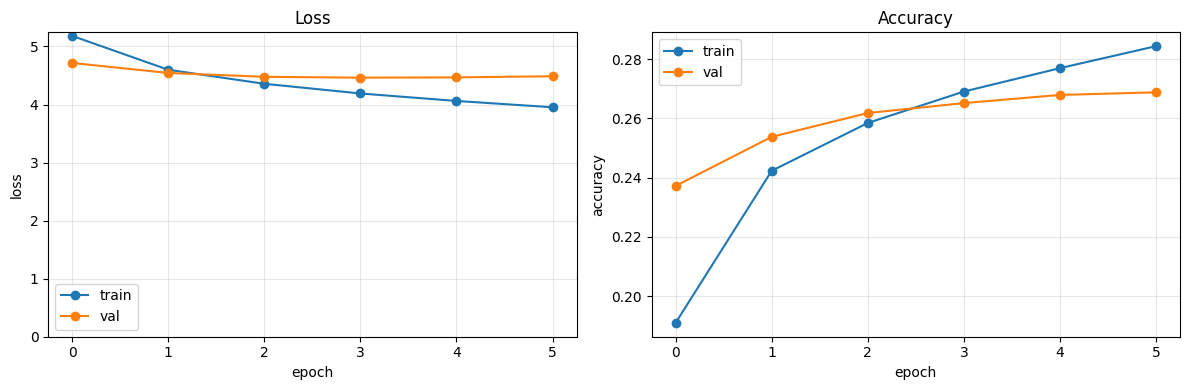

LSTM val perplexity: 86.7


In [ ]:
evaluate_lstm(history_lstm_demo)

In [ ]:
lstm_1 = Sequential([
    Embedding(total_words, 100), # mask zeros = false for T4 GPU
    LSTM(150,dropout=0.2,return_sequences=False),
    Dropout(0.3),
    Dense(total_words, activation='softmax')
 ])
lstm_1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_1.build(input_shape=(None, padding_maxlen - 1))
lstm_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 39, 100)        │     1,502,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15021)          │     2,268,171 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,920,871 (14.96 MB)

 Trainable params: 3,920,871 (14.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_lstm_1 = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('seinfeld_lstm1.keras', monitor='val_loss', save_best_only=True),
]

In [ ]:
history_lstm_1 = lstm_1.fit(
    X_lstm_train, y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks_lstm_1,
)

Epoch 1/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 59s 15ms/step - accuracy: 0.1811 - loss: 5.2782 - val_accuracy: 0.2285 - val_loss: 4.7854
Epoch 2/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2359 - loss: 4.7063 - val_accuracy: 0.2513 - val_loss: 4.5812
Epoch 3/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2506 - loss: 4.4814 - val_accuracy: 0.2601 - val_loss: 4.5014
Epoch 4/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2597 - loss: 4.3320 - val_accuracy: 0.2640 - val_loss: 4.4675
Epoch 5/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - accuracy: 0.2664 - loss: 4.2218 - val_accuracy: 0.2658 - val_loss: 4.4654
Epoch 6/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2719 - loss: 4.1349 - val_accuracy: 0.2686 - val_loss: 4.4681
Epoch 7/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 82s 15ms/step - accuracy: 0.2765 - loss: 4.0655 - val_accuracy: 0.2687 - val_loss: 4.4775


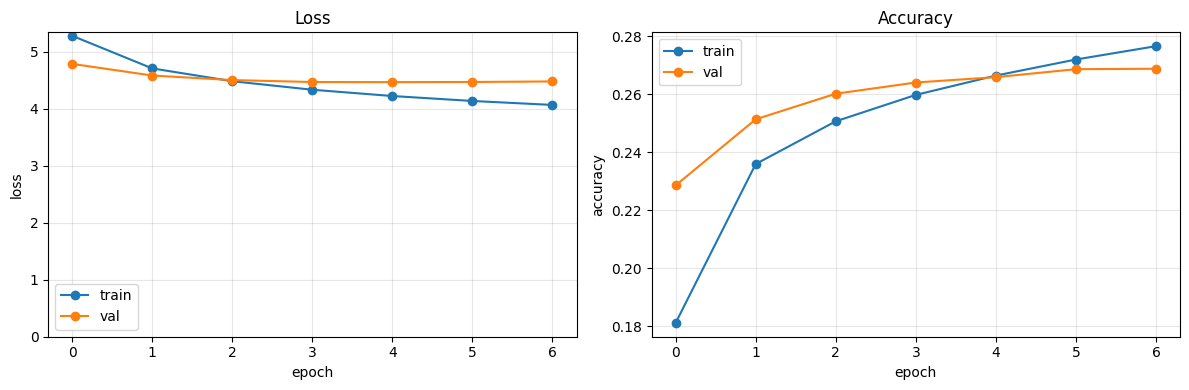

LSTM val perplexity: 87.0


In [ ]:
evaluate_lstm(history_lstm_1)

#### LSTM2

In [ ]:
lstm2 = Sequential([
    Embedding(total_words, 100), # mask zeros = false for T4 GPU
    LSTM(150,dropout=0.2,return_sequences=True),
    Dropout(0.3),
    LSTM(150,dropout=0.2,return_sequences=False),
    Dense(total_words, activation='softmax')
 ])

In [ ]:
lstm2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [ ]:
lstm2.build(input_shape=(None, padding_maxlen - 1))
lstm2.summary()
callbacks_lstm2 = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('seinfeld_lstm2.keras', monitor='val_loss', save_best_only=True),
]

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 39, 100)        │     1,502,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 39, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 39, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15021)          │     2,268,171 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,101,471 (15.65 MB)

 Trainable params: 4,101,471 (15.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm_2 = lstm2.fit(
    X_lstm_train, y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=15,
    batch_size=256,
    callbacks=callbacks_lstm2,
)


Epoch 1/15
1866/1866 ━━━━━━━━━━━━━━━━━━━━ 53s 26ms/step - accuracy: 0.1486 - loss: 5.5193 - val_accuracy: 0.2044 - val_loss: 4.9474
Epoch 2/15
1866/1866 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.2124 - loss: 4.8442 - val_accuracy: 0.2283 - val_loss: 4.7353
Epoch 3/15
1866/1866 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - accuracy: 0.2312 - loss: 4.6277 - val_accuracy: 0.2394 - val_loss: 4.6595
Epoch 4/15
1866/1866 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.2390 - loss: 4.4914 - val_accuracy: 0.2433 - val_loss: 4.6243
Epoch 5/15
1866/1866 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.2458 - loss: 4.3877 - val_accuracy: 0.2479 - val_loss: 4.6174
Epoch 6/15
1866/1866 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.2495 - loss: 4.3032 - val_accuracy: 0.2493 - val_loss: 4.6229
Epoch 7/15
1866/1866 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.2533 - loss: 4.2314 - val_accuracy: 0.2514 - val_loss: 4.6433


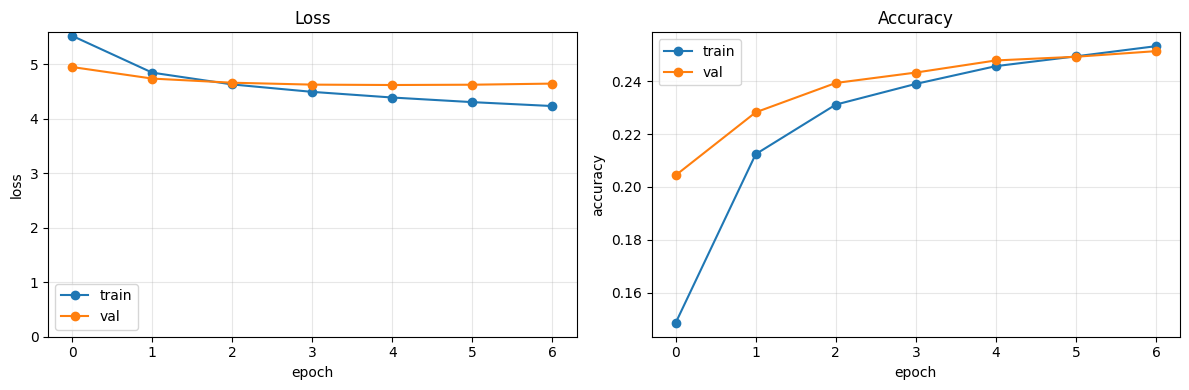

LSTM val perplexity: 101.2


In [ ]:
evaluate_lstm(history_lstm_2)

#### LSTM3 - ADDING REGULARIZATION

In [ ]:
padding_maxlen = 40
vocab_cap = 12000


In [ ]:
tokens_new = Tokenizer(
    num_words=12000,                 # keep only the 12,000 most frequent words
    oov_token='<unk>',               # everything rarer becomes this token
    filters='"#$%&()*+-/:;=@[\\]^_`{|}~\t\n'
)

tokens_new.fit_on_texts(train_lstm_tagged)
total_words_lstm3 = min(len(tokens_new.word_index) + 1, vocab_cap)
print("LSTM vocab size (capped):", total_words)

for tag in ['<eos>', '<jerry>', '<george>', '<elaine>', '<kramer>']:
    idx = tokens_new.word_index.get(tag)
    assert idx is not None and idx < vocab_cap, f"{tag} fell below the vocab cap!"



LSTM vocab size (capped): 12000


In [ ]:
train_seqs_lstm3 = []
for line in train_lstm_tagged:
    token_list = tokens_new.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        train_seqs_lstm3.append(token_list[:i+1])

val_seqs_lstm3 = []
for line in val_lstm_tagged:
    token_list = tokens_new.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        val_seqs_lstm3.append(token_list[:i+1])

#pad
train_seqs_lstm3 = pad_sequences(train_seqs_lstm3, maxlen=padding_maxlen, padding='pre')
val_seqs_lstm3 = pad_sequences(val_seqs_lstm3,   maxlen=padding_maxlen, padding='pre')


In [ ]:
X_lstm3_train,y_lstm3_train,X_lstm3_val,y_lstm3_val = split_for_model(train_seqs_lstm3,val_seqs_lstm3)

The train data shape is: (477673, 39) (477673,)
The val data shape is: (116151, 39) (116151,)


In [ ]:
from keras.regularizers import l2

lstm3 = Sequential([
    Embedding(total_words, 100),                        # mask zeros = false for T4 GPU
    LSTM(150, kernel_regularizer=l2(1e-5)),             # kernel only -> keeps cuDNN fast path
    Dropout(0.2),
    Dense(total_words, activation='softmax',
          kernel_regularizer=l2(1e-5))
])

lstm3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm3.build(input_shape=(None, padding_maxlen - 1))
lstm3.summary()

callbacks_lstm3 = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('seinfeld_lstm_reg.keras', monitor='val_loss', save_best_only=True),
]

history_lstm3 = lstm3.fit(
    X_lstm3_train, y_lstm3_train,
    validation_data=(X_lstm3_val, y_lstm3_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks_lstm3,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 39, 100)        │     1,502,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15021)          │     2,268,171 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,920,871 (14.96 MB)

 Trainable params: 3,920,871 (14.96 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 62s 15ms/step - accuracy: 0.1714 - loss: 5.4037 - val_accuracy: 0.2191 - val_loss: 4.9196
Epoch 2/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 62s 17ms/step - accuracy: 0.2252 - loss: 4.8457 - val_accuracy: 0.2440 - val_loss: 4.6820
Epoch 3/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 59s 16ms/step - accuracy: 0.2440 - loss: 4.6453 - val_accuracy: 0.2519 - val_loss: 4.5910
Epoch 4/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - accuracy: 0.2528 - loss: 4.5386 - val_accuracy: 0.2541 - val_loss: 4.5433
Epoch 5/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 81s 15ms/step - accuracy: 0.2595 - loss: 4.4668 - val_accuracy: 0.2585 - val_loss: 4.5184
Epoch 6/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 82s 15ms/step - accuracy: 0.2642 - loss: 4.4135 - val_accuracy: 0.2610 - val_loss: 4.4916
Epoch 7/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2685 - loss: 4.3760 - val_accuracy: 0.2616 - val_loss: 4.4799
Epoch 8/15
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2725 -

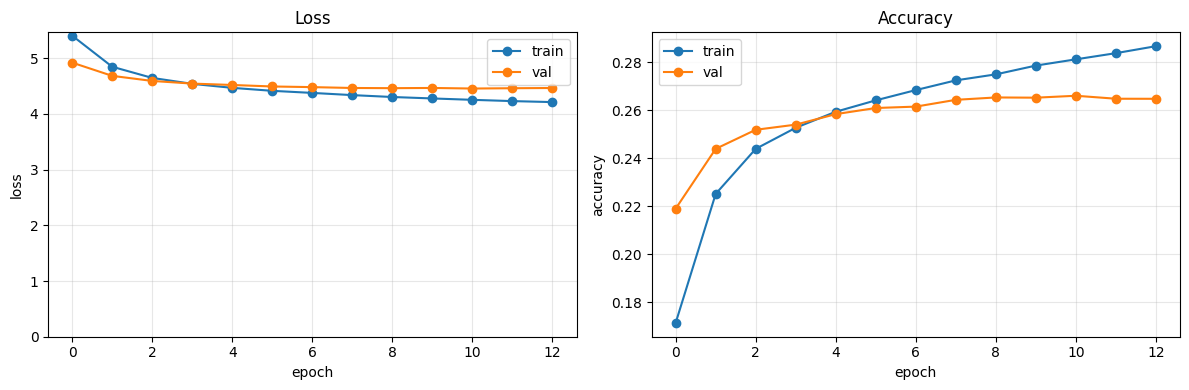

LSTM val perplexity: 86.0


In [ ]:
evaluate_lstm(history_lstm3)

In [ ]:
callbacks_lstm3_sec = [
    #EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('seinfeld_lstm_reg_second.keras', monitor='val_loss', save_best_only=True),
]

In [ ]:
history_lstm3 = lstm3.fit(
    X_lstm3_train, y_lstm3_train,
    validation_data=(X_lstm3_val, y_lstm3_val),
    epochs=5,
    batch_size=128,
    callbacks=callbacks_lstm3_sec,
)

Epoch 1/5
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - accuracy: 0.2840 - loss: 4.2321 - val_accuracy: 0.2653 - val_loss: 4.4651
Epoch 2/5
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2866 - loss: 4.2118 - val_accuracy: 0.2638 - val_loss: 4.4696
Epoch 3/5
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 58s 16ms/step - accuracy: 0.2882 - loss: 4.1949 - val_accuracy: 0.2658 - val_loss: 4.4681
Epoch 4/5
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.2900 - loss: 4.1770 - val_accuracy: 0.2646 - val_loss: 4.4727
Epoch 5/5
3732/3732 ━━━━━━━━━━━━━━━━━━━━ 54s 14ms/step - accuracy: 0.2927 - loss: 4.1581 - val_accuracy: 0.2669 - val_loss: 4.4706


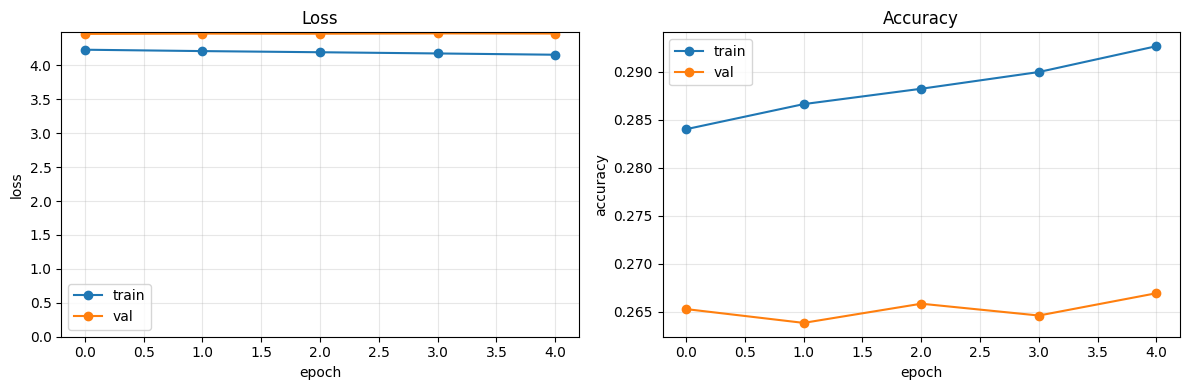

LSTM val perplexity: 86.9


In [ ]:
evaluate_lstm(history_lstm3)

#### Generating text

In [ ]:
def sample(preds, temperature):
    preds = np.asarray(preds).astype('float64')
    preds = np.clip(preds, 1e-10, None)
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.argmax(np.random.multinomial(1, preds, 1))


In [ ]:
def generate_conversation(num_turns, model, temperature, max_words_per_turn, characters):
    # accept a single name or a list; normalize to lowercase
    if isinstance(characters, str):
        characters = [characters]
    characters = [c.strip().lower() for c in characters]

    # turn character names into their <tag> form, keep only ones the model knows
    speaker_tags = [f"<{c}>" for c in characters]
    speaker_tags = [t for t in speaker_tags if t in tokens.word_index]
    if not speaker_tags:
        return "(none of the selected characters are in the model's vocabulary)"

    conversation = ""
    for _ in range(num_turns):
        speaker = np.random.choice(speaker_tags)
        conversation += f"\n{speaker}"

        for _ in range(max_words_per_turn):
            token_list = tokens.texts_to_sequences([conversation])[0]
            token_list = pad_sequences([token_list], maxlen=padding_maxlen - 1, padding='pre')
            predicted = model.predict(token_list, verbose=0)[0]
            next_index = sample(predicted, temperature)
            next_word = tokens.index_word.get(next_index, "")

            if next_word == '<eos>' or next_word == "":
                break
            conversation += " " + next_word

    return conversation.strip()


main_characters = ['jerry', 'george', 'kramer', 'elaine']
side_characters = ['morty', 'helen', 'frank', 'susan', 'estelle', 'peterman', 'puddy', 'jack', 'mickey', 'bania', 'soup_nazi']
side_role       = ['woman', 'man', 'doctor', 'clerk', 'waitress', 'guy', 'manager', 'cop', 'attendant']

generated = generate_conversation(10, lstm_demo, 0.8, 30, main_characters)
print(generated)

<elaine> uh , i got a little more number for a woman . i once knows anything .
<elaine> i didn't pick the office back to you and i did !
<george> five room between her back .
<george> a tuck !
<elaine> and when i think you can feel !
<george> he sees the museum ? oh , it's very much . well , i have to do her out of it .
<jerry> he doesn't even take it
<kramer> yeah , i mean , i'm gonna be up . and i know that breathtaking , i know her on me . i like to get to get together .
<kramer> i know what , uh . you are a wonderful thing .
<kramer> i am like that skin , i feel like to hide the things at a december . i don't know how i was thinking to miss .


In [ ]:
generated = generate_conversation(10, lstm_demo, 0.2, 30, ['jerry','elaine','helen','morty'])
print(generated)

<jerry> i don't know .
<elaine> i don't know .
<elaine> i don't know , i was just a little bit of a lot of a lot of a little bit of a lot of .
<helen> i don't know .
<morty> i know , i was like to see , i thought you were going to be a little bit of a little bit of the same thing .
<jerry> i don't know .
<helen> i don't know .
<morty> i don't know .
<jerry> i don't know .
<helen> i was just a big time .


In [ ]:
generated = generate_conversation(10, lstm_demo, 0.8, 30, ['jerry','elaine','helen','morty'])
print(generated)

<morty> yeah , i'll just go .
<jerry> that was a big word where she asked me to bring off for him ?
<jerry> it was a little army ago ...
<morty> she a blend of his pal .
<jerry> i think this laughs . the first ad , you ever was just inside us when you're going to a dope . you mean , i'm gonna see a game
<helen> we can have to tell him about it , can you get my idea ? you know , it .
<jerry> the victor had in it . there's nothing to play our way to be calling me and i can take you .
<helen> it's not going on .
<helen> this is a black puzzle .
<jerry> if you know what . you can't know how if you see something , and i decided and this guy is an emergency show , she'd like a chair .


In [ ]:
generated = generate_conversation(10, lstm_demo, 0.8, 30, ['jerry','george'])
print(generated)

<jerry> yeah . you are .
<george> i have no idea .
<george> my key is this , i will . um , jerry , what is it ?
<george> we had a problem ?
<george> that's a woman . i mean , we can give me to take him away .
<george> that would not give him to me .
<george> i know what about that .
<jerry> just he says that i have to stop around to eat and have it .
<george> did you say do that i i are looking for anybody ?
<jerry> why ?


### GPT-2 transformer decoder

In [5]:
!pip install -q transformers datasets accelerate

from transformers import (
    GPT2LMHeadModel, GPT2TokenizerFast,
    DataCollatorForLanguageModeling,
    Trainer, TrainingArguments,
)
from datasets import Dataset
import torch
import math

In [ ]:
gpt2_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
len(gpt2_tokenizer)

50257

In [ ]:
train_pgt2_raw = Dataset.from_dict({"text":train_lines})
val_gpt2_raw = Dataset.from_dict({"text":val_lines})

max_len = 64

def tokenize_fn(batch):
    texts = [t + "\n" for t in batch["text"]] #append \n to every line so the odels learn that lines end with newline

    return gpt2_tokenizer(
        batch["text"],
        truncation = True,
        max_length=max_len,
        padding ="max_length",
    )

train_gpt2 = train_pgt2_raw.map(tokenize_fn, batched = True, remove_columns =["text"])
val_gpt2 = val_gpt2_raw.map(tokenize_fn, batched = True, remove_columns =["text"])

print(train_gpt2)


Map:   0%|          | 0/34627 [00:00<?, ? examples/s]

Map:   0%|          | 0/8657 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 34627
})


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
model_gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
model_gpt2.resize_token_embeddings(len(gpt2_tokenizer))
model_gpt2.to(device)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
data_collator = DataCollatorForLanguageModeling(tokenizer = gpt2_tokenizer, mlm = False)


In [ ]:
training_args = TrainingArguments(
    output_dir="./gpt2-seinfeld-cuda",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy ="epoch",
    save_total_limit=1,
    logging_steps=100,
    learning_rate=5e-5,
    warmup_steps=200,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
)
trainer = Trainer(
    model=model_gpt2,
    args= training_args,
    train_dataset=train_gpt2,
    eval_dataset=val_gpt2,
    data_collator=data_collator
)

train_result = trainer.train()


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,2.736785,2.810811
2,2.505931,2.825571
3,2.385627,2.847481


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


In [ ]:
# characters available in this format — must match how they appear in training text (uppercase NAME:)
main_characters = ['JERRY', 'GEORGE', 'ELAINE', 'KRAMER']
side_characters = ['MORTY', 'HELEN', 'FRANK', 'SUSAN', 'ESTELLE',
                   'PETERMAN', 'PUDDY', 'JACK', 'MICKEY', 'BANIA', 'SOUP_NAZI']
side_role       = ['WOMAN', 'MAN', 'DOCTOR', 'CLERK', 'WAITRESS',
                   'GUY', 'MANAGER', 'COP', 'ATTENDANT']

NEWLINE_ID = gpt2_tokenizer.encode("\n")[0]


def generate_gpt2_conversation(num_turns, characters, temperature,
                               max_words_per_turn, history_turns=4):
    # accept a single name or a list; uppercase to match the training format
    if isinstance(characters, str):
        characters = [characters]
    speaker_names = [c.strip().upper() for c in characters]
    if not speaker_names:
        return "(no characters given)"

    turns = []
    for _ in range(num_turns):
        speaker = np.random.choice(speaker_names)
        prompt = "\n".join(turns[-history_turns:] + [f"{speaker}:"])

        inputs = gpt2_tokenizer(prompt, return_tensors="pt").to(device)
        output = model_gpt2.generate(
            **inputs,
            max_new_tokens=max_words_per_turn,
            min_new_tokens=2,
            do_sample=True,
            temperature=temperature,
            top_k=50, top_p=0.95,
            repetition_penalty=1.2,
            pad_token_id=gpt2_tokenizer.eos_token_id,
            eos_token_id=NEWLINE_ID,
        )
        new_text = gpt2_tokenizer.decode(
            output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
        )
        dialogue = new_text.split("\n")[0].strip()
        turns.append(f"{speaker}: {dialogue}")

    return "\n".join(turns)


# usage — same shape as your LSTM call
print(generate_gpt2_conversation(10, main_characters, temperature=0.8, max_words_per_turn = 30))

KRAMER: You're not gonna go out there! (Elaine goes to her bedroom. She makes the door open. Elaine gets back into Kramer's room.)
GEORGE: I gotta go. What's that? They got some big tables on here right here, they want me in there with you?! No no no no
GEORGE: George doesn't understand why it took so long to get my coat! (Elaine gets up and walks over to Jerry.) Hey, if she sees
JERRY: Hi, are ya okay? (George looks at his hand) yeah, well listen, what's this about anyway - I can't do this anymore
GEORGE: Oh well, just make a little visit to see one of them. (Jerry hands Elaine another bottle] George, is that okay? I gotta find
JERRY: Well, how could I not like these places? How could...(George shakes his head in disbelief) *not* like this again!! ...(
KRAMER: You're kidding. (Jerry sits down) You don 't know what you want from the place you have right here?! I'm gonna have no
KRAMER: Just look at me. Yeah! This really isn' all my fault. Because when I tell you I was there, I never to

TypeError: generate_gpt2_conversation() missing 2 required positional arguments: 'temperature' and 'max_words_per_turn'

In [ ]:
print(generate_gpt2_conversation(10, ['JERRY','WOMAN'], temperature=0.8, max_words_per_turn = 30))

WOMAN: What? Why didn't you see that TV commercial? Do the men like it. I mean, look at this woman on her show and she doesn
JERRY: (Looking up to Elaine) You're not supposed into anything. You donAknow about anything! It's just a coincidence! You see me in
WOMAN: Whoa!!! Where's the big deal with this guy?! Whoa!! (Waves them both away) It's very flattering.. This is it
WOMAN: Are we gonna see the same old sitcom for Christmas? (Looks at George behind his back as Kramer enters) Hey. You know I'm watching the
JERRY: Well we'll see what happens if I get caught. (George opens the door.) Oh yeah? Hey, let go of 'em. (George
WOMAN: So you wanna hang around here and catch your mother? Okay, where's he going with that one already? No, wait a second. He might
JERRY: Why don't these guys bring him something to eat? (A woman looks at her watch) Yeah, right, give him to me. Give me
WOMAN: The whole thing about that TV show, it just doesn' have all this funny stuff about its host like some sort..

In [ ]:
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokens, f)